In [2]:
import os, sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc

HOME = os.getenv('HOME')
ROOT = os.getcwd()
print(ROOT)
sys.path.append(ROOT+'/scripts')

import sdds
import teufel

mec2 = sc.m_e*sc.c**2 / sc.e

/home/ulf/Programming/TEUFEL


In [70]:
log_data = teufel.readTeufelBeamLog('chicane_beam.sdds')

In [71]:
log_data.keys()

dict_keys(['x_avg', 'y_avg', 'z_avg', 't', 'x_rms', 'y_rms', 'z_rms', 'bgx_avg', 'bgy_avg', 'bgz_avg', 'gamma', 'delta', 'BF'])

In [72]:
t = np.array(log_data['t'])
x = np.array(log_data['x_avg'])
y = np.array(log_data['y_avg'])
z = np.array(log_data['z_avg'])
x_rms = np.array(log_data['x_rms'])
y_rms = np.array(log_data['y_rms'])
z_rms = np.array(log_data['z_rms'])
bgx = np.array(log_data['bgx_avg'])
bgy = np.array(log_data['bgy_avg'])
bgz = np.array(log_data['bgz_avg'])
gamma = np.array(log_data['gamma'])
delta = np.array(log_data['delta'])
bf = np.array(log_data['BF'])
print(f'{len(t)} data points')

2001 data points


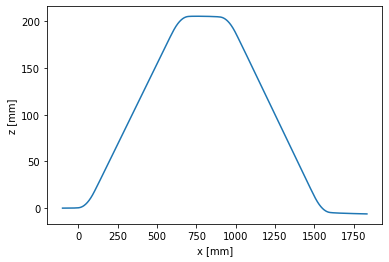

In [73]:
plt.plot(1e3*x, 1e3*z)
plt.xlabel('x [mm]')
plt.ylabel('z [mm]')
plt.show()

### beam transport without energy spread

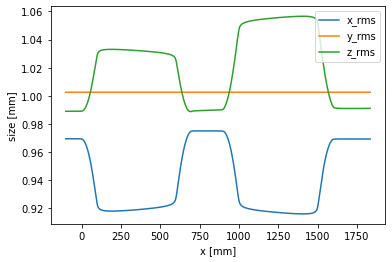

In [52]:
plt.plot(1e3*x, 1e3*x_rms, label="x_rms")
plt.plot(1e3*x, 1e3*y_rms, label="y_rms")
plt.plot(1e3*x, 1e3*z_rms, label="z_rms")
plt.xlabel('x [mm]')
plt.ylabel('size [mm]')
plt.legend()
plt.show()

### beam transport with 1% energy spread

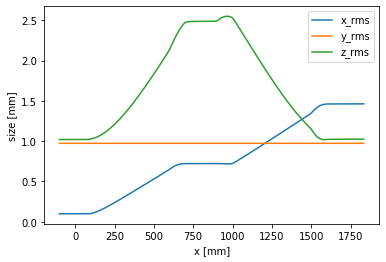

In [74]:
plt.plot(1e3*x, 1e3*x_rms, label="x_rms")
plt.plot(1e3*x, 1e3*y_rms, label="y_rms")
plt.plot(1e3*x, 1e3*z_rms, label="z_rms")
plt.xlabel('x [mm]')
plt.ylabel('size [mm]')
plt.legend()
plt.show()

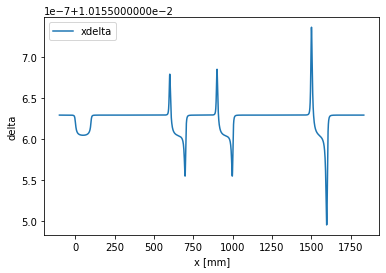

In [75]:
plt.plot(1e3*x, delta, label="xdelta")
plt.xlabel('x [mm]')
plt.ylabel('delta')
plt.legend()
plt.show()

reading  chicane_beam_start.h5
have read 1000 particles.
{'N': 1000, 'x_mean': -0.09999992275634438, 'y_mean': -3.310718421929379e-06, 'z_mean': -3.389425128205375e-05, 'xp_mean': 1.5707963267948972, 'yp_mean': 0.0, 'bgx_mean': 39.11745836782779, 'bgy_mean': 0.0, 'bgz_mean': 0.0, 'E_kin': 19484512.40519149, 'E_tot': 19995511.355187654, 'gamma': 39.130239612699306, 'betagamma': 39.11745836782779, 'x_rms': 9.809745106347353e-05, 'y_rms': 0.000973233431966163, 'z_rms': 0.00101966656278997, 't_rms': 3.40124154420846e-12, 'E_rms': 202934.427558234, 'ex_n_rms': 2.5561705805135723e-18, 'ey_n_rms': 0.0, 'ez_rms': 6.89715608059116e-07}


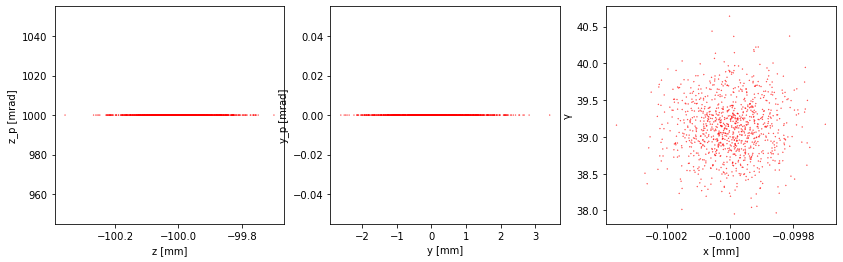

In [76]:
watch = teufel.TeufelWatch.read('chicane_beam_start.h5')
print(watch.parameters())

fig1, ((ax1, ax2, ax3)) = plt.subplots(figsize=(14,4), nrows=1, ncols=3)
ones = np.ones(watch.NOP)
bg = np.sqrt(watch.bgx**2+watch.bgy**2+watch.bgz**2)
ax1.scatter(1e3*watch.x, 1e3*watch.bgx/bg, 0.1*ones, color='r')
ax1.set_xlabel('z [mm]')
ax1.set_ylabel('z_p [mrad]')
ax2.scatter(1e3*watch.y, 1e3*watch.bgy/bg, 0.1*ones, color='r')
ax2.set_xlabel('y [mm]')
ax2.set_ylabel('y_p [mrad]')
ax3.scatter(watch.x, watch.gamma, 0.1*ones, color='r')
ax3.set_xlabel('x [mm]')
ax3.set_ylabel('γ')
plt.show()

reading  chicane_beam_final.h5
have read 1000 particles.
{'N': 1000, 'x_mean': 1.8336937223140595, 'y_mean': -3.310718421929379e-06, 'z_mean': -0.006232979464300972, 'xp_mean': 1.5747186306955328, 'yp_mean': 3.1415926535897944, 'bgx_mean': 39.117157494119866, 'bgy_mean': 0.0, 'bgz_mean': -0.1534109494104048, 'E_kin': 19484512.40368599, 'E_tot': 19995511.353682153, 'gamma': 39.13023960975311, 'betagamma': 39.117458364880626, 'x_rms': 0.0014630251170494057, 'y_rms': 0.000973233431966163, 'z_rms': 0.00102494915773333, 't_rms': 3.4188623842342627e-12, 'E_rms': 202934.4275713523, 'ex_n_rms': 2.9386346585274474e-07, 'ey_n_rms': 5.071998588356887e-17, 'ez_rms': 6.898092650603168e-07}


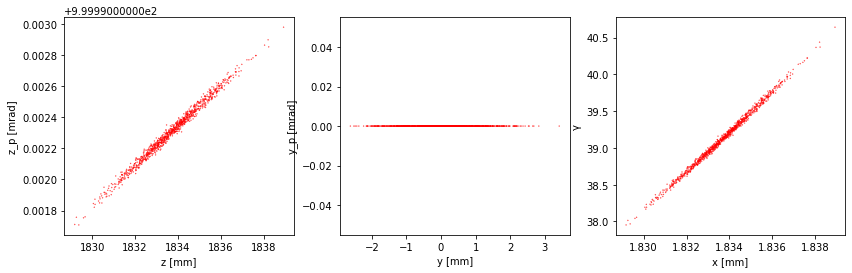

In [77]:
watch = teufel.TeufelWatch.read('chicane_beam_final.h5')
print(watch.parameters())

fig1, ((ax1, ax2, ax3)) = plt.subplots(figsize=(14,4), nrows=1, ncols=3)
ones = np.ones(watch.NOP)
bg = np.sqrt(watch.bgx**2+watch.bgy**2+watch.bgz**2)
ax1.scatter(1e3*watch.x, 1e3*watch.bgx/bg, 0.1*ones, color='r')
ax1.set_xlabel('z [mm]')
ax1.set_ylabel('z_p [mrad]')
ax2.scatter(1e3*watch.y, 1e3*watch.bgy/bg, 0.1*ones, color='r')
ax2.set_xlabel('y [mm]')
ax2.set_ylabel('y_p [mrad]')
ax3.scatter(watch.x, watch.gamma, 0.1*ones, color='r')
ax3.set_xlabel('x [mm]')
ax3.set_ylabel('γ')
plt.show()